In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from wordcloud import WordCloud
import re

In [2]:
df = pd.read_csv("twitter_training.csv", header=None)
df.columns = ['ID', 'Topic', 'Sentiment', 'Text']
df.head()

,ID,Topic,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [3]:
print(df.shape)
print(df['Sentiment'].value_counts())

(74682, 4)
Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


In [4]:
df = df.dropna(subset=['Text'])
print(df.shape)

(73996, 4)


C:\Users\Asus\AppData\Local\Temp\ipykernel_38692\3294622405.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df, palette='Set2',


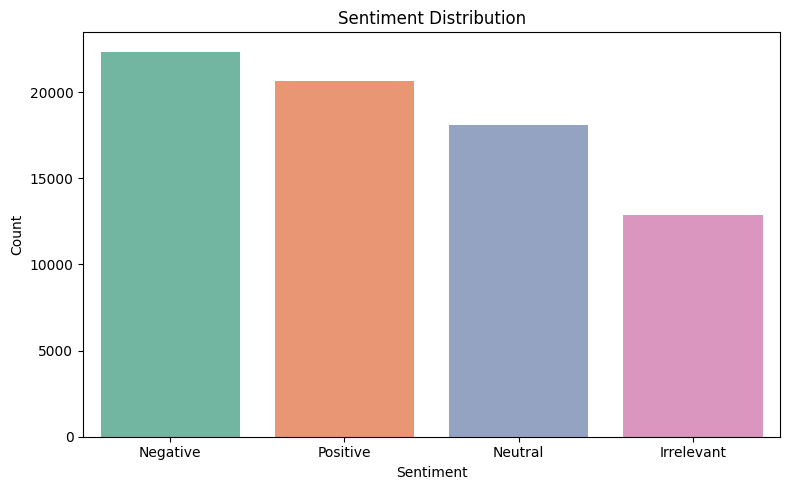

In [5]:
plt.figure(figsize=(8,5))
sns.countplot(x='Sentiment', data=df, palette='Set2',
order=df['Sentiment'].value_counts().index)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('sentiment_distribution.png')
plt.show()

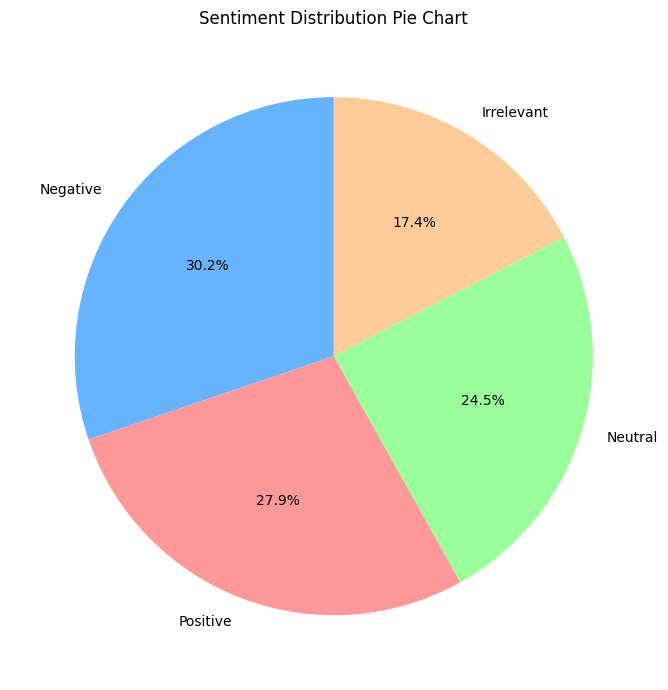

In [6]:
plt.figure(figsize=(7,7))
df['Sentiment'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['#66b3ff','#ff9999','#99ff99','#ffcc99'],
    startangle=90
)
plt.title('Sentiment Distribution Pie Chart')
plt.ylabel('')
plt.tight_layout()
plt.savefig('sentiment_pie.png')
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_38692\3827777650.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Topic', data=df, palette='viridis',


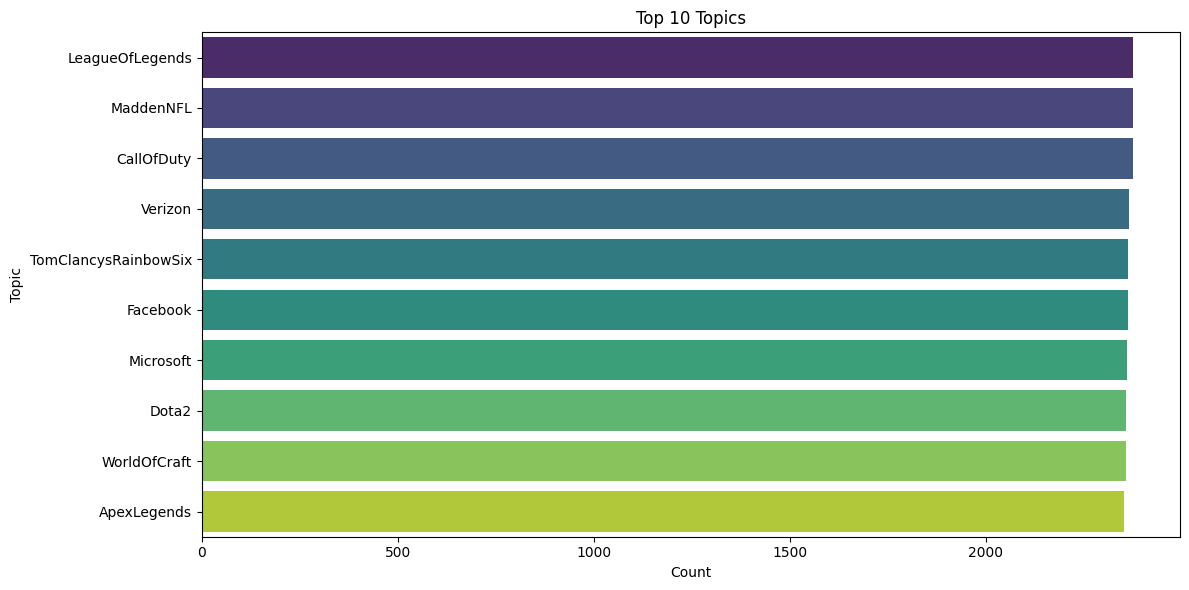

In [7]:
plt.figure(figsize=(12,6))
sns.countplot(y='Topic', data=df, palette='viridis',
order=df['Topic'].value_counts().head(10).index)
plt.title('Top 10 Topics')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('top_topics.png')
plt.show()

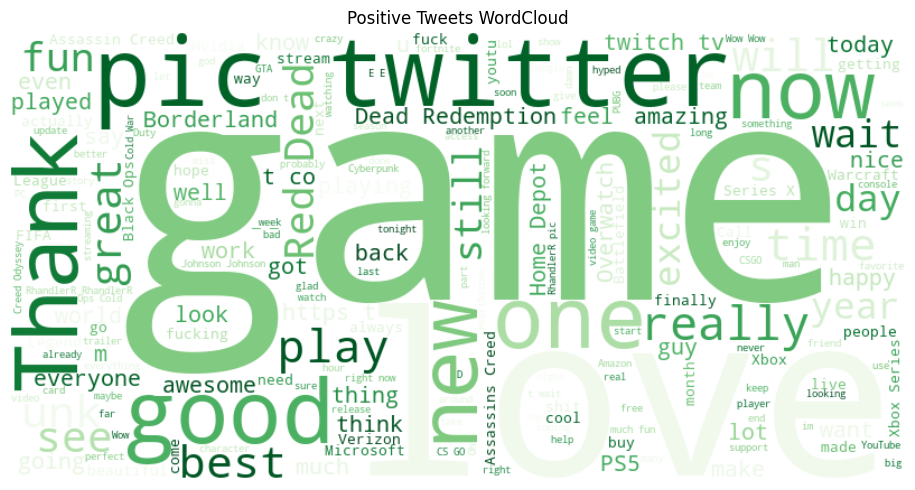

In [8]:
positive_text = ' '.join(df[df['Sentiment']=='Positive']['Text'].astype(str))
wordcloud = WordCloud(width=800, height=400,
background_color='white', colormap='Greens').generate(positive_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Tweets WordCloud')
plt.tight_layout()
plt.savefig('wordcloud_positive.png')
plt.show()

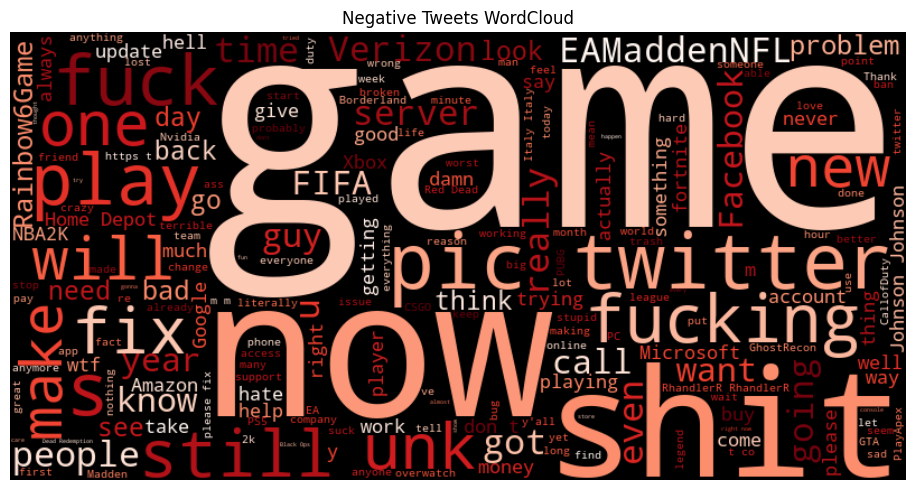

In [9]:
negative_text = ' '.join(df[df['Sentiment']=='Negative']['Text'].astype(str))
wordcloud = WordCloud(width=800, height=400,
background_color='black', colormap='Reds').generate(negative_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Tweets WordCloud')
plt.tight_layout()
plt.savefig('wordcloud_negative.png')
plt.show()